<a href="https://colab.research.google.com/github/marymuthee/Masters_portoflio/blob/main/ship_detector_V1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Automatic Detection of Ship Containers using Segment Anything Model (SAM)**

Port container monitoring is a critical task in logistics, customs control, and urban planning. Manually counting and mapping shipping containers from aerial imagery is time-consuming and error-prone, especially at large port facilities handling thousands of containers simultaneously. This notebook presents an automated, annotation-free pipeline for detecting and counting shipping containers using a combination of high-resolution RGB orthophoto imagery and LiDAR point cloud data.

The pipeline leverages the Segment Anything Model (SAM) developed by Meta AI Research as its core detection engine, combined with LiDAR-derived height filtering to eliminate false positives and isolate elevated objects (containers) from ground-level features.

Unlike supervised deep learning approaches that require thousands of annotated training samples, this pipeline operates without any manual annotation, making it highly transferable to new port scenes and scalable to large datasets.

## **Segment Anything Model (SAM)**

SAM is a foundation model for image segmentation developed by Meta AI Research, released in 2023. It is capable of segmenting any object in any image, zero-shot without task-specific training. SAM accepts optional prompts (points, boxes, or text) but can also operate in fully automatic mode, generating masks for all identifiable objects in an image.



*  Paper: Segment Anything -https://arxiv.org/abs/2304.02643
*   GitHub: https://github.com/facebookresearch/segment-anything

## **Dataset**

The dataset consists of two co-registered data sources covering the same 500m × 500m
port area, acquired on the same date. Both datasets share the same coordinate reference
system (EPSG:32631 — WGS84 / UTM Zone 31N).

| Parameter             | RGB Orthophoto                                      | LiDAR Point Cloud                                        |
|-----------------------|-----------------------------------------------------|----------------------------------------------------------|
| **File**              | BE_ORTHO_27032011_315130_56865_UTM31N.tif           | BE_LIDAR_27032011_315130_56865_UTM31N.las                |
| **Acquisition Date**  | 27 March 2011                                       | 27 March 2011                                            |
| **Coverage**          | 500m × 500m                                         | 500m × 500m                                             |
| **Resolution**        | 5cm GSD                                             | ~20M points (≈ 25cm spacing)                            |
| **Image/Point Size**  | 10,000 × 10,000 pixels                              | 20,022,938 points                                        |
| **Spectral/Attributes**| 3 bands (RGB), uint8                               | X, Y, Z, Intensity, RGB, Return Number                  |
| **Coordinate System** | EPSG:32631 — WGS84 / UTM Zone 31N                  | EPSG:32631 — WGS84 / UTM Zone 31N                       |
                             


> **Note:** A DSM file was provided for the same scene but was **not used** in this
> pipeline, as it excludes mobile objects (containers, vehicles, vessels) by design.
> The raw LiDAR point cloud was used instead, as it captures all objects
> present at the time of acquisition.

## **Environment Setup**
This pipeline runs entirely in **Google Colab** using a free GPU runtime (NVIDIA T4).
All data is loaded directly from **Google Drive**

###  **Requirements**

| Library            | Purpose                                              |
|--------------------|------------------------------------------------------|
| `segment-anything` | Meta's SAM model for automatic mask generation       |
| `rasterio`         | Read/write GeoTIFF orthophoto with georeferencing    |
| `laspy`            | Read LiDAR point cloud (.las format)                 |
| `numpy`            | Array operations and mask creation                   |
| `opencv-python`    | Rotated bounding box fitting and morphological ops   |
| `matplotlib`       | Visualization of detections at each pipeline stage   |
| `geopandas`        | Spatial data handling                                |
| `shapely`          | Geometry operations                                  |
| `torch`            | PyTorch backend for SAM inference                    |







###  **Libraries Installation**

In [ ]:
# Install required libraries
!pip install segment-anything rasterio laspy[lazrs] geopandas shapely -q

# Download SAM pretrained weights (ViT-B variant, ~375MB)
!wget -q https://dl.fbaipublicfiles.com/segment_anything/sam_vit_b_01ec64.pth

print("All dependencies installed")
print("SAM weights downloaded")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 32.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 111.7/111.7 kB 12.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.0/63.0 MB 12.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 kB 8.5 MB/s eta 0:00:00
  Attempting uninstall: opencv-python
    Found existing installation: opencv-python 4.13.0.92
    Uninstalling opencv-python-4.13.0.92:
      Successfully uninstalled opencv-python-4.13.0.92


### **Mount Google Drive**

In [ ]:
#mount drive
from google.colab import drive
drive.mount(  '/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## **Data Loading and Inspection**

### **Libraries**

In [ ]:
#call libraries
import rasterio
import geopandas as gpd
import shapely
import os
import matplotlib.pyplot as plt
import numpy as np
from ultralytics import YOLO
from sahi import AutoDetectionModel
from sahi.predict import get_sliced_prediction

In [ ]:
#image path
image_path="/content/drive/MyDrive/Eo_Project/BE_ORTHO_27032011_315130_56865_UTM31N.tif"
print("File exists:", os.path.exists(image_path))
print("File size:", round(os.path.getsize(image_path) / 1024 / 1024, 2), "MB")

File exists: True
File size: 184.66 MB


In [ ]:
#read image from path
#check crs, widthmheight, bands
with rasterio.open(image_path) as src:
    print("CRS:", src.crs)
    print("Width:", src.width, "px")
    print("Height:", src.height, "px")
    print("Bands:", src.count)
    print("Dtype:", src.dtypes[0])
    print("Resolution (m/px):", src.res)

CRS: EPSG:32631
Width: 10000 px
Height: 10000 px
Bands: 3
Dtype: uint8
Resolution (m/px): (0.05, 0.05)


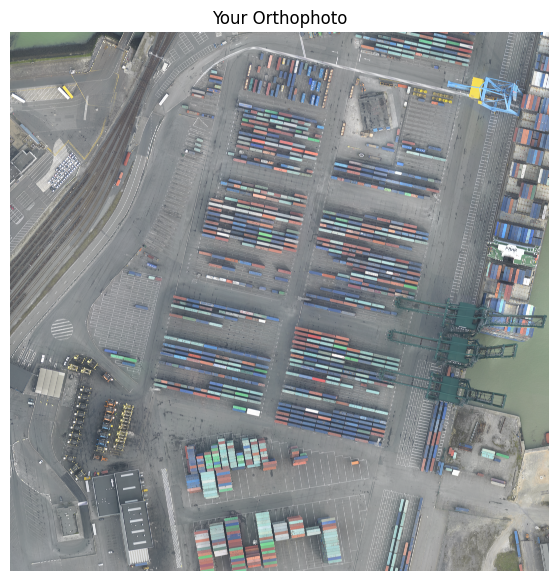

In [ ]:
with rasterio.open(image_path) as src:
    img = src.read([1, 2, 3])  # Read RGB bands

# Rasterio reads as (bands, height, width) ,convert to (height, width, bands)
img = np.moveaxis(img, 0, -1)

plt.figure(figsize=(12, 7))
plt.imshow(img)
plt.title("Your Orthophoto")
plt.axis('off')
plt.show()

In [ ]:
#install SAM
!pip install segment-anything -q
!wget -q https://dl.fbaipublicfiles.com/segment_anything/sam_vit_b_01ec64.pth

print("SAM installed")

SAM installed


In [ ]:
import rasterio
import numpy as np
import matplotlib.pyplot as plt

image_path = '/content/drive/MyDrive/Eo_Project/BE_ORTHO_27032011_315130_56865_UTM31N.tif'

with rasterio.open(image_path) as src:
    # Read at 10% resolution just for preview
    img_overview = src.read(
        [1, 2, 3],
        out_shape=(3, src.height // 10, src.width // 10)
    )
    img_overview = np.moveaxis(img_overview, 0, -1)

plt.figure(figsize=(10, 10))
plt.imshow(img_overview)
plt.title("Full image overview (10% resolution)")
plt.axis('off')
plt.savefig('/content/drive/MyDrive/overview.png', dpi=100, bbox_inches='tight')
plt.close()
print(f"Overview shape: {img_overview.shape} ")
print("Saved to Drive — open overview.png")

Overview shape: (1000, 1000, 3) 
Saved to Drive — open overview.png


In [ ]:
import numpy as np
import torch
import cv2
import pickle
import rasterio
from segment_anything import sam_model_registry, SamAutomaticMaskGenerator

torch.cuda.empty_cache()

sam = sam_model_registry["vit_b"](checkpoint="sam_vit_b_01ec64.pth")
sam.to("cuda" if torch.cuda.is_available() else "cpu")

mask_generator = SamAutomaticMaskGenerator(
    model=sam,
    points_per_side=32,
    pred_iou_thresh=0.88,
    stability_score_thresh=0.92,
    min_mask_region_area=500,
)

image_path = '/content/drive/MyDrive/Eo_Project/BE_ORTHO_27032011_315130_56865_UTM31N.tif'
save_dir = '/content/drive/MyDrive/Eo_Project/'

TILE_SIZE = 512
OVERLAP = 50
QUAD_SIZE = 5000  # process in 5000x5000 quadrants

quadrants = [
    (0, 0, 'q1_topleft'),
    (0, 5000, 'q2_topright'),
    (5000, 0, 'q3_bottomleft'),
    (5000, 5000, 'q4_bottomright'),
]

for (row_off, col_off, qname) in quadrants:
    save_path = f"{save_dir}boxes_{qname}.pkl"

    # Skip if already processed
    import os
    if os.path.exists(save_path):
        print(f"Skipping {qname} — already done")
        continue

    print(f"\n=== Processing {qname} ===")
    q_boxes = []
    tile_count = 0

    with rasterio.open(image_path) as src:
        # Read quadrant
        window = rasterio.windows.Window(col_off, row_off, QUAD_SIZE, QUAD_SIZE)
        quad_img = src.read([1, 2, 3], window=window)
        quad_img = np.moveaxis(quad_img, 0, -1)

    h, w = quad_img.shape[:2]

    for y in range(0, h, TILE_SIZE - OVERLAP):
        for x in range(0, w, TILE_SIZE - OVERLAP):
            x_end = min(x + TILE_SIZE, w)
            y_end = min(y + TILE_SIZE, h)
            tile = quad_img[y:y_end, x:x_end]

            if tile.shape[0] < 64 or tile.shape[1] < 64:
                continue

            # Skip empty/ground tiles
            if np.std(np.mean(tile, axis=2)) < 15:
                continue

            tile_masks = mask_generator.generate(tile)

            for mask in tile_masks:
                m = mask['segmentation'].astype(np.uint8)
                contours, _ = cv2.findContours(m, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
                if not contours:
                    continue
                cnt = max(contours, key=cv2.contourArea)
                rect = cv2.minAreaRect(cnt)

                (cx, cy), (bw, bh), angle = rect
                # Offset to full image coordinates
                cx += col_off + x
                cy += row_off + y
                rect_global = ((cx, cy), (bw, bh), angle)

                if min(bw, bh) > 0:
                    q_boxes.append({
                        'rect': rect_global,
                        'area': mask['area'],
                        'aspect_ratio': max(bw, bh) / min(bw, bh),
                        'box_w': bw,
                        'box_h': bh
                    })

            tile_count += 1
            if tile_count % 10 == 0:
                print(f"  {qname}: tile {tile_count}, boxes so far: {len(q_boxes)}")

            del tile_masks
            torch.cuda.empty_cache()

    # Save quadrant results immediately
    with open(save_path, 'wb') as f:
        pickle.dump(q_boxes, f)
    print(f"  {qname} done — {len(q_boxes)} boxes saved")
    del quad_img
    torch.cuda.empty_cache()

print("\nAll quadrants done! ")


=== Processing q1_topleft ===
  q1_topleft: tile 10, boxes so far: 471
  q1_topleft: tile 20, boxes so far: 1057
  q1_topleft: tile 30, boxes so far: 1445
  q1_topleft: tile 40, boxes so far: 1969
  q1_topleft: tile 50, boxes so far: 2544
  q1_topleft: tile 60, boxes so far: 2856
  q1_topleft: tile 70, boxes so far: 3254
  q1_topleft: tile 80, boxes so far: 3709
  q1_topleft: tile 90, boxes so far: 4166
  q1_topleft: tile 100, boxes so far: 4524
  q1_topleft done — 4591 boxes saved

=== Processing q2_topright ===
  q2_topright: tile 10, boxes so far: 531
  q2_topright: tile 20, boxes so far: 1043
  q2_topright: tile 30, boxes so far: 1656
  q2_topright: tile 40, boxes so far: 2227
  q2_topright: tile 50, boxes so far: 2704
  q2_topright: tile 60, boxes so far: 3177
  q2_topright: tile 70, boxes so far: 3596
  q2_topright: tile 80, boxes so far: 4064
  q2_topright: tile 90, boxes so far: 4492
  q2_topright: tile 100, boxes so far: 4925
  q2_topright done — 5149 boxes saved

=== Process

In [ ]:
import pickle
import os

save_dir = '/content/drive/MyDrive/Eo_Project/'
all_boxes = []

for qname in ['q1_topleft', 'q2_topright', 'q3_bottomleft', 'q4_bottomright']:
    save_path = f"{save_dir}boxes_{qname}.pkl"

    if os.path.exists(save_path):
        with open(save_path, 'rb') as f:
            q_boxes = pickle.load(f)
        print(f"{qname}: {len(q_boxes)} boxes loaded")
        all_boxes.extend(q_boxes)
    else:
        print(f"{qname}: NOT FOUND")

print(f"\nTotal boxes combined: {len(all_boxes)}")
rotated_boxes = all_boxes

q1_topleft: 4591 boxes loaded
q2_topright: 5149 boxes loaded
q3_bottomleft: 4492 boxes loaded
q4_bottomright: 3855 boxes loaded

Total boxes combined: 18087


In [ ]:
import numpy as np

filtered_boxes = []

for b in rotated_boxes:
    if (b['aspect_ratio'] > 2.5 and    # long and narrow
        b['aspect_ratio'] < 15 and     # remove extreme shapes (roads, cranes)
        b['area'] > 5000 and           # not tiny noise
        b['area'] < 100000):           # not merged groups

        filtered_boxes.append(b)

print(f"Before filter: {len(rotated_boxes)}")
print(f"After filter:  {len(filtered_boxes)}")

# Stats
areas = [b['area'] for b in filtered_boxes]
aspects = [b['aspect_ratio'] for b in filtered_boxes]
print(f"\nFiltered area — min: {min(areas):.0f}, max: {max(areas):.0f}, mean: {np.mean(areas):.0f}")
print(f"Filtered aspect ratio — min: {min(aspects):.1f}, max: {max(aspects):.1f}, mean: {np.mean(aspects):.1f}")

Before filter: 18087
After filter:  1660

Filtered area — min: 5003, max: 95583, mean: 13625
Filtered aspect ratio — min: 2.5, max: 15.0, mean: 4.7


In [ ]:
import rasterio
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import cv2

image_path = '/content/drive/MyDrive/Eo_Project/BE_ORTHO_27032011_315130_56865_UTM31N.tif'

# Load at 20% resolution for visualization
with rasterio.open(image_path) as src:
    scale = 0.2
    img_vis = src.read(
        [1, 2, 3],
        out_shape=(3, int(src.height * scale), int(src.width * scale))
    )
    img_vis = np.moveaxis(img_vis, 0, -1)

fig, ax = plt.subplots(1, 1, figsize=(15, 15))
ax.imshow(img_vis)

for b in filtered_boxes:
    box_points = cv2.boxPoints(b['rect'])
    box_points = np.intp(box_points * scale)  # scale points to match downsampled image
    polygon = plt.Polygon(box_points,
                          linewidth=0.5,
                          edgecolor='lime',
                          facecolor='none')
    ax.add_patch(polygon)

ax.set_title(f"Filtered containers: {len(filtered_boxes)}")
ax.axis('off')
plt.savefig('/content/drive/MyDrive/Eo_Project/full_detection.png', dpi=150, bbox_inches='tight')
plt.close()
print("Saved  — check full_detection.png in your Drive")

Saved  — check full_detection.png in your Drive


In [ ]:
import numpy as np
import cv2

def compute_iou(box1, box2):
    # Convert rotated rects to contours and compute intersection
    pts1 = cv2.boxPoints(box1).astype(np.float32)
    pts2 = cv2.boxPoints(box2).astype(np.float32)

    # Use bounding rect overlap as approximation (faster)
    r1 = cv2.boundingRect(pts1)
    r2 = cv2.boundingRect(pts2)

    x1 = max(r1[0], r2[0])
    y1 = max(r1[1], r2[1])
    x2 = min(r1[0]+r1[2], r2[0]+r2[2])
    y2 = min(r1[1]+r1[3], r2[1]+r2[3])

    if x2 < x1 or y2 < y1:
        return 0.0

    intersection = (x2-x1) * (y2-y1)
    area1 = r1[2] * r1[3]
    area2 = r2[2] * r2[3]
    union = area1 + area2 - intersection

    return intersection / union if union > 0 else 0.0

# Apply NMS
IOU_THRESHOLD = 0.3
kept = []
used = [False] * len(filtered_boxes)

# Sort by area descending (keep larger boxes)
sorted_boxes = sorted(filtered_boxes, key=lambda b: b['area'], reverse=True)

for i, box in enumerate(sorted_boxes):
    if used[i]:
        continue
    kept.append(box)
    for j in range(i+1, len(sorted_boxes)):
        if used[j]:
            continue
        iou = compute_iou(box['rect'], sorted_boxes[j]['rect'])
        if iou > IOU_THRESHOLD:
            used[j] = True

print(f"Before NMS: {len(filtered_boxes)}")
print(f"After NMS:  {len(kept)}")
filtered_boxes = kept

Before NMS: 1660
After NMS:  1274


In [ ]:
import rasterio
import numpy as np
import matplotlib.pyplot as plt
import cv2

image_path = '/content/drive/MyDrive/Eo_Project/BE_ORTHO_27032011_315130_56865_UTM31N.tif'

with rasterio.open(image_path) as src:
    scale = 0.2
    img_vis = src.read(
        [1, 2, 3],
        out_shape=(3, int(src.height * scale), int(src.width * scale))
    )
    img_vis = np.moveaxis(img_vis, 0, -1)

fig, ax = plt.subplots(1, 1, figsize=(15, 15))
ax.imshow(img_vis)

for b in filtered_boxes:
    box_points = cv2.boxPoints(b['rect'])
    box_points = np.intp(box_points * scale)
    polygon = plt.Polygon(box_points,
                          linewidth=0.5,
                          edgecolor='lime',
                          facecolor='none')
    ax.add_patch(polygon)

ax.set_title(f"After NMS: {len(filtered_boxes)} containers")
ax.axis('off')
plt.savefig('/content/drive/MyDrive/Eo_Project/detection_nms.png', dpi=150, bbox_inches='tight')
plt.close()
print("Saved  — check detection_nms.png in your Drive")

Saved  — check detection_nms.png in your Drive


In [ ]:
import numpy as np
import rasterio
import cv2

image_path = '/content/drive/MyDrive/Eo_Project/BE_ORTHO_27032011_315130_56865_UTM31N.tif'

# Load full image once
with rasterio.open(image_path) as src:
    full_img = src.read([1, 2, 3])
    full_img = np.moveaxis(full_img, 0, -1)

color_filtered = []

for b in filtered_boxes:
    cx, cy = b['rect'][0]
    bw, bh = b['rect'][1]
    cx, cy = int(cx), int(cy)
    half_w = int(max(bw, bh) / 2)
    half_h = int(min(bw, bh) / 2)

    # Crop region around box center
    x1 = max(0, cx - half_w)
    x2 = min(full_img.shape[1], cx + half_w)
    y1 = max(0, cy - half_h)
    y2 = min(full_img.shape[0], cy + half_h)

    crop = full_img[y1:y2, x1:x2]
    if crop.size == 0:
        continue

    # Convert to HSV and measure saturation
    hsv = cv2.cvtColor(crop, cv2.COLOR_RGB2HSV)
    mean_saturation = np.mean(hsv[:, :, 1])

    # Containers are colorful (saturation > 30)
    # Roads/buildings are gray (saturation < 30)
    if mean_saturation > 30:
        color_filtered.append(b)

print(f"Before color filter: {len(filtered_boxes)}")
print(f"After color filter:  {len(color_filtered)}")
filtered_boxes = color_filtered

Before color filter: 1274
After color filter:  883


In [ ]:
import rasterio
import numpy as np
import matplotlib.pyplot as plt
import cv2

with rasterio.open(image_path) as src:
    scale = 0.2
    img_vis = src.read(
        [1, 2, 3],
        out_shape=(3, int(src.height * scale), int(src.width * scale))
    )
    img_vis = np.moveaxis(img_vis, 0, -1)

fig, ax = plt.subplots(1, 1, figsize=(15, 15))
ax.imshow(img_vis)

for b in filtered_boxes:
    box_points = cv2.boxPoints(b['rect'])
    box_points = np.intp(box_points * scale)
    polygon = plt.Polygon(box_points,
                          linewidth=0.5,
                          edgecolor='lime',
                          facecolor='none')
    ax.add_patch(polygon)

ax.set_title(f"After color filter: {len(filtered_boxes)} containers")
ax.axis('off')
plt.savefig('/content/drive/MyDrive/Eo_Project/detection_color.png', dpi=150, bbox_inches='tight')
plt.close()
print("Saved — check detection_color.png in your Drive")

Saved — check detection_color.png in your Drive


##Vsiualzing Quadrants indivudally

In [ ]:
import rasterio
import numpy as np
import matplotlib.pyplot as plt
import cv2
import pickle

image_path = '/content/drive/MyDrive/Eo_Project/BE_ORTHO_27032011_315130_56865_UTM31N.tif'
save_dir = '/content/drive/MyDrive/Eo_Project/'

quadrants = [
    ('q1_topleft',     0,    0),
    ('q2_topright',    0,    5000),
    ('q3_bottomleft',  5000, 0),
    ('q4_bottomright', 5000, 5000),
]

QUAD_SIZE = 5000
scale = 0.2

for qname, row_off, col_off in quadrants:
    # Load quadrant boxes
    with open(f"{save_dir}boxes_{qname}.pkl", 'rb') as f:
        q_boxes = pickle.load(f)

    # Apply same filters
    filtered = [b for b in q_boxes if
                b['aspect_ratio'] > 2.5 and
                b['aspect_ratio'] < 15 and
                b['area'] > 5000 and
                b['area'] < 100000]

    # Load quadrant image at 20%
    with rasterio.open(image_path) as src:
        window = rasterio.windows.Window(col_off, row_off, QUAD_SIZE, QUAD_SIZE)
        q_img = src.read([1, 2, 3], window=window,
                         out_shape=(3, int(QUAD_SIZE * scale), int(QUAD_SIZE * scale)))
        q_img = np.moveaxis(q_img, 0, -1)

    fig, ax = plt.subplots(1, 1, figsize=(10, 10))
    ax.imshow(q_img)

    for b in filtered:
        # Adjust coordinates to quadrant-local space
        (cx, cy), (bw, bh), angle = b['rect']
        cx_local = cx - col_off
        cy_local = cy - row_off
        local_rect = ((cx_local, cy_local), (bw, bh), angle)

        box_points = cv2.boxPoints(local_rect)
        box_points = np.intp(box_points * scale)
        polygon = plt.Polygon(box_points,
                              linewidth=0.5,
                              edgecolor='lime',
                              facecolor='none')
        ax.add_patch(polygon)

    ax.set_title(f"{qname}: {len(filtered)} boxes")
    ax.axis('off')
    plt.savefig(f"{save_dir}viz_{qname}.png", dpi=150, bbox_inches='tight')
    plt.close()
    print(f"{qname} saved  — {len(filtered)} boxes")

q1_topleft saved  — 318 boxes
q2_topright saved  — 527 boxes
q3_bottomleft saved  — 399 boxes
q4_bottomright saved  — 416 boxes


# RUN SAM on 5*5 Grid

In [ ]:
import numpy as np
import torch
import cv2
import pickle
import os
import rasterio
from segment_anything import sam_model_registry, SamAutomaticMaskGenerator

torch.cuda.empty_cache()

sam = sam_model_registry["vit_b"](checkpoint="sam_vit_b_01ec64.pth")
sam.to("cuda" if torch.cuda.is_available() else "cpu")

mask_generator = SamAutomaticMaskGenerator(
    model=sam,
    points_per_side=32,
    pred_iou_thresh=0.88,
    stability_score_thresh=0.92,
    min_mask_region_area=500,
)

image_path = '/content/drive/MyDrive/Eo_Project/BE_ORTHO_27032011_315130_56865_UTM31N.tif'
save_dir = '/content/drive/MyDrive/Eo_Project/zones/'
os.makedirs(save_dir, exist_ok=True)

ZONE_SIZE = 2000
TILE_SIZE = 512
OVERLAP = 50
GRID = 5  # 5x5

for row in range(GRID):
    for col in range(GRID):
        zone_name = f"zone_r{row}_c{col}"
        save_path = f"{save_dir}{zone_name}.pkl"

        # Skip if already processed
        if os.path.exists(save_path):
            print(f"Skipping {zone_name} ")
            continue

        row_off = row * ZONE_SIZE
        col_off = col * ZONE_SIZE

        print(f"\n=== Processing {zone_name} (row={row}, col={col}) ===")
        zone_boxes = []
        tile_count = 0

        with rasterio.open(image_path) as src:
            window = rasterio.windows.Window(col_off, row_off, ZONE_SIZE, ZONE_SIZE)
            zone_img = src.read([1, 2, 3], window=window)
            zone_img = np.moveaxis(zone_img, 0, -1)

        h, w = zone_img.shape[:2]

        for y in range(0, h, TILE_SIZE - OVERLAP):
            for x in range(0, w, TILE_SIZE - OVERLAP):
                x_end = min(x + TILE_SIZE, w)
                y_end = min(y + TILE_SIZE, h)
                tile = zone_img[y:y_end, x:x_end]

                if tile.shape[0] < 64 or tile.shape[1] < 64:
                    continue

                # Skip empty/gray tiles
                if np.std(np.mean(tile, axis=2)) < 15:
                    continue

                tile_masks = mask_generator.generate(tile)

                for mask in tile_masks:
                    m = mask['segmentation'].astype(np.uint8)
                    contours, _ = cv2.findContours(m, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
                    if not contours:
                        continue
                    cnt = max(contours, key=cv2.contourArea)
                    rect = cv2.minAreaRect(cnt)

                    (cx, cy), (bw, bh), angle = rect
                    # Offset to full image coordinates
                    cx += col_off + x
                    cy += row_off + y
                    rect_global = ((cx, cy), (bw, bh), angle)

                    if min(bw, bh) > 0:
                        zone_boxes.append({
                            'rect': rect_global,
                            'area': mask['area'],
                            'aspect_ratio': max(bw, bh) / min(bw, bh),
                            'box_w': bw,
                            'box_h': bh
                        })

                tile_count += 1
                del tile_masks
                torch.cuda.empty_cache()

        # Save zone immediately
        with open(save_path, 'wb') as f:
            pickle.dump(zone_boxes, f)
        print(f"{zone_name} done — {len(zone_boxes)} boxes saved ")
        del zone_img
        torch.cuda.empty_cache()
print("\nAll zones done! ")

Skipping zone_r0_c0 
Skipping zone_r0_c1 
Skipping zone_r0_c2 
Skipping zone_r0_c3 
Skipping zone_r0_c4 

=== Processing zone_r1_c0 (row=1, col=0) ===
zone_r1_c0 done — 1018 boxes saved 

=== Processing zone_r1_c1 (row=1, col=1) ===
zone_r1_c1 done — 446 boxes saved 

=== Processing zone_r1_c2 (row=1, col=2) ===
zone_r1_c2 done — 808 boxes saved 

=== Processing zone_r1_c3 (row=1, col=3) ===
zone_r1_c3 done — 765 boxes saved 

=== Processing zone_r1_c4 (row=1, col=4) ===
zone_r1_c4 done — 977 boxes saved 

=== Processing zone_r2_c0 (row=2, col=0) ===
zone_r2_c0 done — 704 boxes saved 

=== Processing zone_r2_c1 (row=2, col=1) ===
zone_r2_c1 done — 802 boxes saved 

=== Processing zone_r2_c2 (row=2, col=2) ===
zone_r2_c2 done — 688 boxes saved 

=== Processing zone_r2_c3 (row=2, col=3) ===
zone_r2_c3 done — 539 boxes saved 

=== Processing zone_r2_c4 (row=2, col=4) ===
zone_r2_c4 done — 1111 boxes saved 

=== Processing zone_r3_c0 (row=3, col=0) ===
zone_r3_c0 done — 1260 boxes saved 



In [ ]:
import pickle
import os

save_dir = '/content/drive/MyDrive/Eo_Project/zones/'

all_boxes = []
total_zones = 0

for row in range(5):
    for col in range(5):
        zone_name = f"zone_r{row}_c{col}"
        save_path = f"{save_dir}{zone_name}.pkl"

        if os.path.exists(save_path):
            with open(save_path, 'rb') as f:
                zone_boxes = pickle.load(f)
            print(f"{zone_name}: {len(zone_boxes)} boxes ")
            all_boxes.extend(zone_boxes)
            total_zones += 1
        else:
            print(f"{zone_name}: NOT FOUND ")

print(f"\nZones loaded: {total_zones}/25")
print(f"Total boxes: {len(all_boxes)}")
rotated_boxes = all_boxes

zone_r0_c0: 705 boxes ✅
zone_r0_c1: 855 boxes ✅
zone_r0_c2: 1057 boxes ✅
zone_r0_c3: 980 boxes ✅
zone_r0_c4: 1048 boxes ✅
zone_r1_c0: 1018 boxes ✅
zone_r1_c1: 446 boxes ✅
zone_r1_c2: 808 boxes ✅
zone_r1_c3: 765 boxes ✅
zone_r1_c4: 977 boxes ✅
zone_r2_c0: 704 boxes ✅
zone_r2_c1: 802 boxes ✅
zone_r2_c2: 688 boxes ✅
zone_r2_c3: 539 boxes ✅
zone_r2_c4: 1111 boxes ✅
zone_r3_c0: 1260 boxes ✅
zone_r3_c1: 873 boxes ✅
zone_r3_c2: 728 boxes ✅
zone_r3_c3: 1054 boxes ✅
zone_r3_c4: 648 boxes ✅
zone_r4_c0: 480 boxes ✅
zone_r4_c1: 666 boxes ✅
zone_r4_c2: 639 boxes ✅
zone_r4_c3: 427 boxes ✅
zone_r4_c4: 481 boxes ✅

Zones loaded: 25/25
Total boxes: 19759


In [ ]:
import matplotlib.pyplot as plt
import cv2
import numpy as np

scale = 0.2

with rasterio.open(image_path) as src:
    img_vis = src.read(
        [1, 2, 3],
        out_shape=(3, int(src.height * scale), int(src.width * scale))
    )
    img_vis = np.moveaxis(img_vis, 0, -1)

fig, ax = plt.subplots(1, 1, figsize=(15, 15))
ax.imshow(img_vis)

for b in filtered_boxes:
    box_points = cv2.boxPoints(b['rect'])
    box_points = np.intp(box_points * scale)
    polygon = plt.Polygon(box_points,
                          linewidth=0.5,
                          edgecolor='lime',
                          facecolor='none')
    ax.add_patch(polygon)

ax.set_title(f"5x5 grid result: {len(filtered_boxes)} containers")
ax.axis('off')
plt.savefig('/content/drive/MyDrive/Eo_Project/detection_5x5.png', dpi=150, bbox_inches='tight')
plt.close()
print("Saved — check detection_5x5.png in your Drive")

Saved — check detection_5x5.png in your Drive


In [ ]:
import matplotlib.pyplot as plt
import cv2
import numpy as np
import rasterio

image_path = '/content/drive/MyDrive/Eo_Project/BE_ORTHO_27032011_315130_56865_UTM31N.tif'

scale = 0.2

with rasterio.open(image_path) as src:
    img_vis = src.read(
        [1, 2, 3],
        out_shape=(3, int(src.height * scale), int(src.width * scale))
    )
    img_vis = np.moveaxis(img_vis, 0, -1)

# Reconstruct each stage
stage1 = rotated_boxes  # raw

stage2 = [b for b in rotated_boxes if
          b['aspect_ratio'] > 2.5 and
          b['aspect_ratio'] < 15 and
          b['area'] > 5000 and
          b['area'] < 100000]

stage3 = color_filtered  # after color

stage4 = filtered_boxes  # after NMS

stages = [
    (stage1, 'Raw SAM output',        'red'),
    (stage2, 'After shape filter',    'yellow'),
    (stage3, 'After color filter',    'cyan'),
    (stage4, 'After NMS (final)',      'lime'),
]

for boxes, title, color in stages:
    fig, ax = plt.subplots(1, 1, figsize=(15, 15))
    ax.imshow(img_vis)

    for b in boxes:
        box_points = cv2.boxPoints(b['rect'])
        box_points = np.intp(box_points * scale)
        polygon = plt.Polygon(box_points,
                              linewidth=0.5,
                              edgecolor=color,
                              facecolor='none')
        ax.add_patch(polygon)

    ax.set_title(f"{title}: {len(boxes)} boxes")
    ax.axis('off')

    fname = title.lower().replace(' ', '_').replace('(', '').replace(')', '')
    plt.savefig(f'/content/drive/MyDrive/Eo_Project/{fname}.png',
                dpi=150, bbox_inches='tight')
    plt.close()
    print(f"Saved: {fname}.png — {len(boxes)} boxes")

print("\nAll 4 stages saved to Drive")

Saved: raw_sam_output.png — 19759 boxes
Saved: after_shape_filter.png — 1722 boxes
Saved: after_color_filter.png — 1202 boxes
Saved: after_nms_final.png — 909 boxes

All 4 stages saved to Drive


In [ ]:
import numpy as np
import cv2
import rasterio

print("Applying color filter directly on raw SAM output...")

color_filtered = []
for b in rotated_boxes:
    cx, cy = b['rect'][0]
    bw, bh = b['rect'][1]
    cx, cy = int(cx), int(cy)
    half_w = int(max(bw, bh) / 2)
    half_h = int(min(bw, bh) / 2)

    x1 = max(0, cx - half_w)
    x2 = min(full_img.shape[1], cx + half_w)
    y1 = max(0, cy - half_h)
    y2 = min(full_img.shape[0], cy + half_h)

    crop = full_img[y1:y2, x1:x2]
    if crop.size == 0:
        continue

    hsv = cv2.cvtColor(crop, cv2.COLOR_RGB2HSV)
    mean_saturation = np.mean(hsv[:, :, 1])

    if mean_saturation > 30:
        color_filtered.append(b)

print(f"Raw SAM:          {len(rotated_boxes)}")
print(f"After color only: {len(color_filtered)}")

Applying color filter directly on raw SAM output...
Raw SAM:          19759
After color only: 7423


In [ ]:
import numpy as np
from collections import defaultdict

# For each box, count how many neighbors it has within a radius
NEIGHBOR_RADIUS = 200  # pixels — adjust based on container spacing
MIN_NEIGHBORS = 3      # must have at least 3 nearby boxes to be kept

# Extract centers
centers = np.array([b['rect'][0] for b in rotated_boxes])

kept = []
for i, b in enumerate(rotated_boxes):
    cx, cy = b['rect'][0]

    # Count neighbors within radius
    dists = np.sqrt((centers[:, 0] - cx)**2 + (centers[:, 1] - cy)**2)
    neighbors = np.sum(dists < NEIGHBOR_RADIUS) - 1  # exclude self

    if neighbors >= MIN_NEIGHBORS:
        kept.append(b)

print(f"Raw SAM:                {len(rotated_boxes)}")
print(f"After density filter:   {len(kept)}")

Raw SAM:                19759
After density filter:   19733


# Using lidar

In [ ]:
!pip install laspy[lazrs] -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 649.3/649.3 kB 17.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.1/86.1 kB 7.5 MB/s eta 0:00:00


In [ ]:
import laspy
import numpy as np

las_path = '/content/drive/MyDrive/Eo_Project/BE_LIDAR_27032011_315130_56865_UTM31N.las'

las = laspy.read(las_path)

print("LiDAR file loaded")
print(f"Number of points: {len(las.points):,}")
print(f"CRS/VLRs: {las.header.vlrs}")
print(f"\nPoint attributes: {list(las.point_format.dimension_names)}")


LiDAR file loaded
Number of points: 20,022,938
CRS/VLRs: [<GeoKeyDirectoryVlr(3 geo_keys)>, <GeoAsciiParamsVlr(['WGS 84 / UTM zone 31N'])>]

Point attributes: ['X', 'Y', 'Z', 'intensity', 'return_number', 'number_of_returns', 'scan_direction_flag', 'edge_of_flight_line', 'classification', 'synthetic', 'key_point', 'withheld', 'scan_angle_rank', 'user_data', 'point_source_id', 'gps_time', 'red', 'green', 'blue']


In [ ]:
import numpy as np

# Convert to numpy arrays
x = np.array(las.x)
y = np.array(las.y)
z = np.array(las.z)
classification = np.array(las.classification)

print(f"Z mean: {z.mean():.2f}m")
print(f"Z std:  {z.std():.2f}m")

# Check classifications
unique_classes, counts = np.unique(classification, return_counts=True)
print(f"\nPoint classifications:")
for c, n in zip(unique_classes, counts):
    print(f"  Class {c}: {n:,} points")

# Check Z distribution
percentiles = np.percentile(z, [1, 5, 25, 50, 75, 95, 99])
print(f"\nZ percentiles:")
labels = ['1%', '5%', '25%', '50%', '75%', '95%', '99%']
for l, p in zip(labels, percentiles):
    print(f"  {l}: {p:.2f}m")

Z mean: 52.68m
Z std:  8.98m

Point classifications:
  Class 0: 20,022,938 points

Z percentiles:
  1%: 44.06m
  5%: 48.77m
  25%: 49.70m
  50%: 49.91m
  75%: 50.33m
  95%: 66.76m
  99%: 99.51m


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Correct bounds from your LiDAR metadata
# X: 513000 → 513500
# Y: 5686500 → 5687000

x_min, x_max = 513150, 513350
y_min, y_max = 5686650, 5686850  # ← fixed, was wrong before

area = (x >= x_min) & (x <= x_max) & (y >= y_min) & (y <= y_max)
x_a = x[area]
y_a = y[area]
z_a = z[area]

print(f"Points in area: {len(z_a):,}")
print(f"Z range: {z_a.min():.2f} → {z_a.max():.2f}")

plt.figure(figsize=(12, 10))
sc = plt.scatter(x_a, y_a, c=z_a, cmap='RdYlGn', s=0.5, vmin=49, vmax=62)
plt.colorbar(sc, label='Height (m)')
plt.title("Raw LiDAR points colored by height\nGreen=ground, Red=elevated")
plt.axis('equal')
plt.savefig('/content/drive/MyDrive/Eo_Project/lidar_points_raw.png', dpi=150, bbox_inches='tight')
plt.close()
print("Saved ")

Points in area: 3,206,297
Z range: 49.50 → 102.49
Saved 


In [ ]:
import numpy as np
import cv2
import rasterio
import matplotlib.pyplot as plt

# From the plot:
# Ground = ~50m (red)
# Containers = 52m → 62m+ (orange to dark green)

GROUND_Z = 50.0
min_h = 51.5   # clearly above ground
max_h = 69.0   # capture all container heights including tall stacks

mask = (z >= min_h) & (z <= max_h)
x_c = x[mask]
y_c = y[mask]

print(f"Points captured: {len(x_c):,} ({len(x_c)/len(z)*100:.1f}%)")

with rasterio.open(image_path) as src:
    transform = src.transform
    width = src.width
    height = src.height

col_idx = ((x_c - transform.c) / transform.a).astype(int)
row_idx = ((y_c - transform.f) / transform.e).astype(int)

valid = (col_idx >= 0) & (col_idx < width) & (row_idx >= 0) & (row_idx < height)
container_mask = np.zeros((height, width), dtype=np.uint8)
container_mask[row_idx[valid], col_idx[valid]] = 1

# Mild dilation just to connect adjacent points
kernel = np.ones((3, 3), np.uint8)
container_mask_final = cv2.dilate(container_mask, kernel, iterations=2)

print(f"Mask pixels: {container_mask_final.sum():,} ({container_mask_final.sum()/1e8*100:.1f}%)")

# Visualize
with rasterio.open(image_path) as src:
    scale = 0.2
    img_vis = src.read([1,2,3], out_shape=(3, int(src.height*scale), int(src.width*scale)))
    img_vis = np.moveaxis(img_vis, 0, -1)

mask_vis = cv2.resize(container_mask_final, (img_vis.shape[1], img_vis.shape[0]), interpolation=cv2.INTER_NEAREST)

fig, axes = plt.subplots(1, 2, figsize=(20, 10))
axes[0].imshow(img_vis)
axes[0].set_title("Original")
axes[0].axis('off')
axes[1].imshow(mask_vis, cmap='hot')
axes[1].set_title(f"LiDAR mask (51.5-63m)\n({container_mask_final.sum()/1e6:.1f}M pixels, {container_mask_final.sum()/1e8*100:.1f}%)")
axes[1].axis('off')

plt.savefig('/content/drive/MyDrive/Eo_Project/lidar_mask_final.png', dpi=150, bbox_inches='tight')
plt.close()
print("Saved  — check lidar_mask_final.png")
np.save('/content/drive/MyDrive/Eo_Project/container_mask_final.npy', container_mask_final)

Points captured: 3,736,054 (18.7%)
Mask pixels: 17,177,768 (17.2%)
Saved  — check lidar_mask_final.png


##fIlter using lidar

In [ ]:
import numpy as np
import cv2
import pickle
import os

# Load all 25 zone boxes
save_dir = '/content/drive/MyDrive/Eo_Project/zones/'
all_boxes = []

for row in range(5):
    for col in range(5):
        zone_name = f"zone_r{row}_c{col}"
        save_path = f"{save_dir}{zone_name}.pkl"
        if os.path.exists(save_path):
            with open(save_path, 'rb') as f:
                all_boxes.extend(pickle.load(f))

print(f"Total SAM boxes: {len(all_boxes)}")

# Filter: keep boxes whose center is in LiDAR mask
lidar_filtered = []
for b in all_boxes:
    cx, cy = b['rect'][0]
    cx, cy = int(cx), int(cy)

    # Check bounds
    if cx < 0 or cx >= 10000 or cy < 0 or cy >= 10000:
        continue

    # Keep if center pixel is in LiDAR mask
    if container_mask_final[cy, cx] == 1:
        lidar_filtered.append(b)

print(f"After LiDAR filter: {len(lidar_filtered)}")

Total SAM boxes: 19759
After LiDAR filter: 5226


In [ ]:
import matplotlib.pyplot as plt
import cv2
import numpy as np
import rasterio

with rasterio.open(image_path) as src:
    scale = 0.2
    img_vis = src.read(
        [1, 2, 3],
        out_shape=(3, int(src.height * scale), int(src.width * scale))
    )
    img_vis = np.moveaxis(img_vis, 0, -1)

fig, ax = plt.subplots(1, 1, figsize=(15, 15))
ax.imshow(img_vis)

for b in lidar_filtered:
    box_points = cv2.boxPoints(b['rect'])
    box_points = np.intp(box_points * scale)
    polygon = plt.Polygon(box_points,
                          linewidth=0.5,
                          edgecolor='lime',
                          facecolor='none')
    ax.add_patch(polygon)

ax.set_title(f"LiDAR filtered: {len(lidar_filtered)} boxes")
ax.axis('off')
plt.savefig('/content/drive/MyDrive/Eo_Project/lidar_filtered.png', dpi=150, bbox_inches='tight')
plt.close()
print("Saved— check lidar_filtered.png")

Saved— check lidar_filtered.png


In [ ]:
import numpy as np
import cv2

# Step 1 — Remove tiny fragments (partial container detections)
shape_filtered = [b for b in lidar_filtered if
                  b['area'] > 3000 and        # remove tiny fragments
                  b['area'] < 150000 and      # remove oversized merged blobs
                  b['aspect_ratio'] > 1.8]    # remove square shapes (vehicles, buildings)

print(f"After shape filter: {len(shape_filtered)}")

# Step 2 — NMS to remove duplicate boxes on same container
IOU_THRESHOLD = 0.3
sorted_boxes = sorted(shape_filtered, key=lambda b: b['area'], reverse=True)
used = [False] * len(sorted_boxes)
kept = []

for i, box in enumerate(sorted_boxes):
    if used[i]:
        continue
    kept.append(box)
    for j in range(i+1, len(sorted_boxes)):
        if used[j]:
            continue
        pts1 = cv2.boxPoints(box['rect']).astype(np.float32)
        pts2 = cv2.boxPoints(sorted_boxes[j]['rect']).astype(np.float32)
        r1 = cv2.boundingRect(pts1)
        r2 = cv2.boundingRect(pts2)
        x1 = max(r1[0], r2[0])
        y1 = max(r1[1], r2[1])
        x2 = min(r1[0]+r1[2], r2[0]+r2[2])
        y2 = min(r1[1]+r1[3], r2[1]+r2[3])
        if x2 < x1 or y2 < y1:
            continue
        intersection = (x2-x1)*(y2-y1)
        union = r1[2]*r1[3] + r2[2]*r2[3] - intersection
        if union > 0 and intersection/union > IOU_THRESHOLD:
            used[j] = True

print(f"After NMS:          {len(kept)}")
filtered_boxes = kept
print(f"\nFinal count: {len(filtered_boxes)}")

After shape filter: 1718
After NMS:          1365

Final count: 1365


In [ ]:
import matplotlib.pyplot as plt
import cv2
import numpy as np
import rasterio

with rasterio.open(image_path) as src:
    scale = 0.2
    img_vis = src.read(
        [1, 2, 3],
        out_shape=(3, int(src.height * scale), int(src.width * scale))
    )
    img_vis = np.moveaxis(img_vis, 0, -1)

fig, ax = plt.subplots(1, 1, figsize=(15, 15))
ax.imshow(img_vis)

for b in filtered_boxes:
    box_points = cv2.boxPoints(b['rect'])
    box_points = np.intp(box_points * scale)
    polygon = plt.Polygon(box_points,
                          linewidth=0.5,
                          edgecolor='lime',
                          facecolor='none')
    ax.add_patch(polygon)

ax.set_title(f"Final result: {len(filtered_boxes)} containers")
ax.axis('off')
plt.savefig('/content/drive/MyDrive/Eo_Project/final_result.png', dpi=150, bbox_inches='tight')
plt.close()
print("Saved — check final_result.png")

Saved — check final_result.png


# Trace missing containers

In [ ]:
import rasterio
import numpy as np
import matplotlib.pyplot as plt

with rasterio.open(image_path) as src:
    scale = 0.1  # very small for quick overview
    img_small = src.read(
        [1, 2, 3],
        out_shape=(3, int(src.height * scale), int(src.width * scale))
    )
    img_small = np.moveaxis(img_small, 0, -1)

# Plot with grid lines showing pixel coordinates
fig, ax = plt.subplots(1, 1, figsize=(10, 10))
ax.imshow(img_small)

# Add grid every 1000px (100px at 10% scale)
for x in range(0, 10000, 1000):
    ax.axvline(x * scale, color='red', linewidth=0.5, alpha=0.7)
    ax.text(x * scale, 10, str(x), color='red', fontsize=7)
for y in range(0, 10000, 1000):
    ax.axhline(y * scale, color='red', linewidth=0.5, alpha=0.7)
    ax.text(5, y * scale, str(y), color='red', fontsize=7)

ax.set_title("Grid overlay — identify ship coordinates")
ax.axis('off')
plt.savefig('/content/drive/MyDrive/Eo_Project/grid_overlay.png', dpi=150, bbox_inches='tight')
plt.close()
print("Saved  — check grid_overlay.png")

Saved  — check grid_overlay.png


In [ ]:
import numpy as np

SHIP_X_MIN, SHIP_X_MAX = 9000, 10000
SHIP_Y_MIN, SHIP_Y_MAX = 1000, 6000

def get_ship_boxes(boxes):
    return [b for b in boxes
            if SHIP_X_MIN < b['rect'][0][0] < SHIP_X_MAX
            and SHIP_Y_MIN < b['rect'][0][1] < SHIP_Y_MAX]

raw_ship = get_ship_boxes(all_boxes)
lidar_ship = get_ship_boxes(lidar_filtered)
killed = [b for b in raw_ship if b not in lidar_ship]

print(f"Raw SAM ship:       {len(raw_ship)}")
print(f"After LiDAR filter: {len(lidar_ship)}")
print(f"Killed by LiDAR:    {len(killed)}")

# Stats of killed boxes
if killed:
    areas = [b['area'] for b in killed]
    aspects = [b['aspect_ratio'] for b in killed]
    print(f"\nKilled boxes stats:")
    print(f"Area   — min: {min(areas):.0f}, max: {max(areas):.0f}, mean: {np.mean(areas):.0f}")
    print(f"Aspect — min: {min(aspects):.1f}, max: {max(aspects):.1f}, mean: {np.mean(aspects):.1f}")

Raw SAM ship:       1471
After LiDAR filter: 675
Killed by LiDAR:    796

Killed boxes stats:
Area   — min: 10, max: 128519, mean: 3257
Aspect — min: 1.0, max: 44.3, mean: 3.5


In [ ]:
import laspy
import numpy as np
import rasterio

# Reload LiDAR
las = laspy.read('/content/drive/MyDrive/Eo_Project/BE_LIDAR_27032011_315130_56865_UTM31N.las')
x = np.array(las.x)
y = np.array(las.y)
z = np.array(las.z)

print(f"LiDAR bounds:")
print(f"X: {x.min():.1f} → {x.max():.1f}")
print(f"Y: {y.min():.1f} → {y.max():.1f}")

# From transform:
# X = 513000 + col * 0.05  → col = (X - 513000) / 0.05
# Y = 5687000 + row * (-0.05) → row = (5687000 - Y) / 0.05

# Ship is at pixel x:9000-10000, y:1000-6000
# Convert to geo:
x_min_geo = 513000 + 9000 * 0.05   # 513450
x_max_geo = 513000 + 10000 * 0.05  # 513500
y_max_geo = 5687000 - 1000 * 0.05  # 5686950
y_min_geo = 5687000 - 6000 * 0.05  # 5686700

print(f"\nShip geo bounds:")
print(f"X: {x_min_geo:.1f} → {x_max_geo:.1f}")
print(f"Y: {y_min_geo:.1f} → {y_max_geo:.1f}")

# Get ship points
ship_pts = (x >= x_min_geo) & (x <= x_max_geo) & \
           (y >= y_min_geo) & (y <= y_max_geo)
z_ship = z[ship_pts]

print(f"\nLiDAR points in ship area: {len(z_ship):,}")
if len(z_ship) > 0:
    for p in [0, 5, 25, 50, 75, 90, 95, 99, 100]:
        print(f"  {p}%: {np.percentile(z_ship, p):.2f}m")

LiDAR bounds:
X: 513000.0 → 513500.0
Y: 5686500.0 → 5687000.0

Ship geo bounds:
X: 513450.0 → 513500.0
Y: 5686700.0 → 5686950.0

LiDAR points in ship area: 954,015
  0%: 43.13m
  5%: 44.05m
  25%: 49.87m
  50%: 62.81m
  75%: 76.52m
  90%: 80.05m
  95%: 88.49m
  99%: 132.17m
  100%: 149.47m


In [ ]:
import numpy as np
import cv2
import rasterio
import matplotlib.pyplot as plt

# Two height ranges:
# Yard containers: 51.5 - 63m
# Ship containers: 62 - 90m (overlapping intentionally)
# Combined: 51.5 - 90m

GROUND_Z = 49.9
min_h = 51.5
max_h = 90.0  # extended to cover ship containers

mask = (z >= min_h) & (z <= max_h)
x_c = x[mask]
y_c = y[mask]

with rasterio.open(image_path) as src:
    transform = src.transform
    width = src.width
    height = src.height

col_idx = ((x_c - transform.c) / transform.a).astype(int)
row_idx = ((y_c - transform.f) / transform.e).astype(int)

valid = (col_idx >= 0) & (col_idx < width) & (row_idx >= 0) & (row_idx < height)
container_mask = np.zeros((height, width), dtype=np.uint8)
container_mask[row_idx[valid], col_idx[valid]] = 1

# Mild dilation
kernel = np.ones((3, 3), np.uint8)
container_mask_final = cv2.dilate(container_mask, kernel, iterations=2)

print(f"Mask pixels: {container_mask_final.sum():,} ({container_mask_final.sum()/1e8*100:.1f}%)")

# Visualize
with rasterio.open(image_path) as src:
    scale = 0.2
    img_vis = src.read([1,2,3], out_shape=(3, int(src.height*scale), int(src.width*scale)))
    img_vis = np.moveaxis(img_vis, 0, -1)

mask_vis = cv2.resize(container_mask_final, (img_vis.shape[1], img_vis.shape[0]), interpolation=cv2.INTER_NEAREST)

fig, axes = plt.subplots(1, 2, figsize=(20, 10))
axes[0].imshow(img_vis)
axes[0].set_title("Original")
axes[0].axis('off')
axes[1].imshow(mask_vis, cmap='hot')
axes[1].set_title(f"Extended mask (51.5-90m)\n({container_mask_final.sum()/1e6:.1f}M pixels, {container_mask_final.sum()/1e8*100:.1f}%)")
axes[1].axis('off')

plt.savefig('/content/drive/MyDrive/Eo_Project/lidar_mask_extended.png', dpi=150, bbox_inches='tight')
plt.close()
print("Saved  — check lidar_mask_extended.png")

np.save('/content/drive/MyDrive/Eo_Project/container_mask_final.npy', container_mask_final)

Mask pixels: 18,783,504 (18.8%)
Saved  — check lidar_mask_extended.png


In [ ]:
import numpy as np
import cv2
import pickle
import os

# Reload all SAM boxes
save_dir = '/content/drive/MyDrive/Eo_Project/zones/'
all_boxes = []
for row in range(5):
    for col in range(5):
        path = f"{save_dir}zone_r{row}_c{col}.pkl"
        if os.path.exists(path):
            with open(path, 'rb') as f:
                all_boxes.extend(pickle.load(f))

print(f"Total SAM boxes: {len(all_boxes)}")

# Step 1 — LiDAR filter with new mask
lidar_filtered = []
for b in all_boxes:
    cx, cy = int(b['rect'][0][0]), int(b['rect'][0][1])
    if 0 <= cx < 10000 and 0 <= cy < 10000:
        if container_mask_final[cy, cx] == 1:
            lidar_filtered.append(b)

print(f"After LiDAR filter: {len(lidar_filtered)}")

# Step 2 — Zone specific shape filter
SHIP_X_MIN, SHIP_X_MAX = 9000, 10000
SHIP_Y_MIN, SHIP_Y_MAX = 1000, 6000

shape_filtered = []
for b in lidar_filtered:
    cx, cy = b['rect'][0]
    in_ship = SHIP_X_MIN < cx < SHIP_X_MAX and SHIP_Y_MIN < cy < SHIP_Y_MAX

    if in_ship:
        if b['area'] > 300 and b['area'] < 80000 and b['aspect_ratio'] > 1.3:
            shape_filtered.append(b)
    else:
        if b['area'] > 3000 and b['area'] < 150000 and b['aspect_ratio'] > 1.8:
            shape_filtered.append(b)

print(f"After shape filter: {len(shape_filtered)}")

# Step 3 — NMS
IOU_THRESHOLD = 0.4
sorted_boxes = sorted(shape_filtered, key=lambda b: b['area'], reverse=True)
used = [False] * len(sorted_boxes)
kept = []

for i, box in enumerate(sorted_boxes):
    if used[i]:
        continue
    kept.append(box)
    for j in range(i+1, len(sorted_boxes)):
        if used[j]:
            continue
        pts1 = cv2.boxPoints(box['rect']).astype(np.float32)
        pts2 = cv2.boxPoints(sorted_boxes[j]['rect']).astype(np.float32)
        r1 = cv2.boundingRect(pts1)
        r2 = cv2.boundingRect(pts2)
        x1 = max(r1[0], r2[0])
        y1 = max(r1[1], r2[1])
        x2 = min(r1[0]+r1[2], r2[0]+r2[2])
        y2 = min(r1[1]+r1[3], r2[1]+r2[3])
        if x2 < x1 or y2 < y1:
            continue
        intersection = (x2-x1)*(y2-y1)
        union = r1[2]*r1[3] + r2[2]*r2[3] - intersection
        if union > 0 and intersection/union > IOU_THRESHOLD:
            used[j] = True

filtered_boxes = kept
print(f"After NMS:          {len(filtered_boxes)}")

# Ship count
ship_count = sum(1 for b in filtered_boxes
                 if SHIP_X_MIN < b['rect'][0][0] < SHIP_X_MAX
                 and SHIP_Y_MIN < b['rect'][0][1] < SHIP_Y_MAX)
print(f"\nYard boxes: {len(filtered_boxes) - ship_count}")
print(f"Ship boxes: {ship_count}")

Total SAM boxes: 19759
After LiDAR filter: 5784
After shape filter: 2101
After NMS:          1790

Yard boxes: 1401
Ship boxes: 389


In [ ]:
import matplotlib.pyplot as plt
import cv2
import numpy as np
import rasterio

with rasterio.open(image_path) as src:
    scale = 0.2
    img_vis = src.read(
        [1, 2, 3],
        out_shape=(3, int(src.height * scale), int(src.width * scale))
    )
    img_vis = np.moveaxis(img_vis, 0, -1)

# Rebuild each stage
stage1 = all_boxes

stage2 = lidar_filtered

SHIP_X_MIN, SHIP_X_MAX = 9000, 10000
SHIP_Y_MIN, SHIP_Y_MAX = 1000, 6000

stage3 = []
for b in lidar_filtered:
    cx, cy = b['rect'][0]
    in_ship = SHIP_X_MIN < cx < SHIP_X_MAX and SHIP_Y_MIN < cy < SHIP_Y_MAX
    if in_ship:
        if b['area'] > 300 and b['area'] < 80000 and b['aspect_ratio'] > 1.3:
            stage3.append(b)
    else:
        if b['area'] > 3000 and b['area'] < 150000 and b['aspect_ratio'] > 1.8:
            stage3.append(b)

stage4 = filtered_boxes  # after NMS

stages = [
    (stage1, 'Raw SAM output',       'red'),
    (stage2, 'After LiDAR filter',   'yellow'),
    (stage3, 'After shape filter',   'cyan'),
    (stage4, 'After NMS (final)',    'lime'),
]

for boxes, title, color in stages:
    fig, ax = plt.subplots(1, 1, figsize=(15, 15))
    ax.imshow(img_vis)

    for b in boxes:
        box_points = cv2.boxPoints(b['rect'])
        box_points = np.intp(box_points * scale)
        polygon = plt.Polygon(box_points,
                              linewidth=0.5,
                              edgecolor=color,
                              facecolor='none')
        ax.add_patch(polygon)

    ax.set_title(f"{title}: {len(boxes)} boxes")
    ax.axis('off')

    fname = title.lower().replace(' ', '_').replace('(', '').replace(')', '')
    path = f'/content/drive/MyDrive/Eo_Project/stage_{fname}.png'
    plt.savefig(path, dpi=150, bbox_inches='tight')
    plt.close()
    print(f"Saved: {fname}.png — {len(boxes)} boxes ")

print("\nAll stages saved")

Saved: raw_sam_output.png — 19759 boxes 
Saved: after_lidar_filter.png — 5784 boxes 
Saved: after_shape_filter.png — 2101 boxes 
Saved: after_nms_final.png — 1790 boxes 

All stages saved


In [ ]:
import json
import cv2
import rasterio
import numpy as np

with rasterio.open(image_path) as src:
    transform = src.transform

def pixel_to_geo(px, py, transform):
    gx = transform.c + float(px) * transform.a
    gy = transform.f + float(py) * transform.e
    return gx, gy

features = []
for i, b in enumerate(filtered_boxes):
    box_points = cv2.boxPoints(b['rect'])

    geo_points = []
    for px, py in box_points:
        gx, gy = pixel_to_geo(px, py, transform)
        geo_points.append([gx, gy])
    geo_points.append(geo_points[0])  # close polygon

    feature = {
        "type": "Feature",
        "geometry": {
            "type": "Polygon",
            "coordinates": [geo_points]
        },
        "properties": {
            "id": int(i),
            "area_px": float(round(b['area'], 2)),
            "aspect_ratio": float(round(b['aspect_ratio'], 2)),
            "zone": "ship" if (9000 < b['rect'][0][0] < 10000 and
                               1000 < b['rect'][0][1] < 6000) else "yard"
        }
    }
    features.append(feature)

geojson = {
    "type": "FeatureCollection",
    "crs": {"type": "name", "properties": {"name": "EPSG:32631"}},
    "features": features
}

output_path = '/content/drive/MyDrive/Eo_Project/containers_final.geojson'
with open(output_path, 'w') as f:
    json.dump(geojson, f)

print(f"Exported {len(features)} containers")
print(f"  Yard: {sum(1 for f in features if f['properties']['zone'] == 'yard')}")
print(f"  Ship: {sum(1 for f in features if f['properties']['zone'] == 'ship')}")
print(f"Saved to: {output_path}")

Exported 1790 containers
  Yard: 1401
  Ship: 389
Saved to: /content/drive/MyDrive/Eo_Project/containers_final.geojson
